# Pre-processing the dataset:

In [132]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

DATASET_PATH = "../datasets"
df = pd.read_csv(f"{DATASET_PATH}/labeled_data/final_training_dataset_ready.csv")

# todo: recency score - figure out a good balance
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (90 * 24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])
df["name_len"] = df["filename"].apply(len)
df["path_len"] = df["path"].apply(len)
df["path_depth"] = df["path"].apply(lambda p: p.count("/") + p.count("\\"))

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(4, 4),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

df

,filename,path,extension,size_bytes,mod_time_unix,source_user,source_type,label_finance,label_hr,label_it,label_general,recency_score,size_logged,name_len,path_len,path_depth
0,client.ovpn,C:\Users\root\OneDrive - Corp\Backups\Code\sid...,.ovpn,51671,1.700438e+09,dev_injector,secret_injection,0,0,1,1,0.104055,10.852671,11,70,8
1,GIPSA Personnel Directory.doc,C:\Users\root\Downloads\ISOs\Personnel,.doc,83886,1.707394e+09,root,govdoc_real,0,1,0,1,0.114735,11.337226,29,38,5
2,InteractionHandler.xcs,C:\Program Files\Microsoft Office\root\Office1...,.xcs,1215,1.709692e+09,jo,system_noise,0,0,0,0,0.118762,7.103322,22,94,11
3,XFX05900 Front End Operations Guide V10.docx,Z:\Support\Knowledge_Base\Articles,.docx,178257,1.537954e+09,wjones,govdoc_real,0,0,0,0,0.032781,12.090987,44,34,3
4,api-273aa1bf.slo,\\wsl$\Debian\home\robert42\git\phabricator\sr...,.slo,27208766,1.754471e+09,faker_github_gen,dependency_noise,0,0,0,0,0.375714,17.119050,16,174,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2413,best_robust.htm,C:\Windows\Help\Tours\htmlTour,.htm,8350,1.681214e+09,pat,system_noise,0,0,0,0,0.082765,9.030137,15,30,4
2414,GRBQ141-2537G-C15[350-390].qxd,C:\Users\leejohnny\Documents\Old_Files\Archive...,.qxd,723517,1.635851e+09,leejohnny,govdoc_real,0,0,0,0,0.055815,13.491881,30,51,5
2415,Americana - Oscar 2023.pub,Z:\Public\Transfer\Oscar,.pub,2013265,1.677167e+09,robertjohnson,govdoc_real,0,0,0,0,0.079346,14.515269,26,24,3
2416,flat.php,\\wsl$\Debian\home\sharon66\git\internet-platf...,.php,961,1.683165e+09,sharon66,github_real,0,0,0,0,0.084520,6.869014,8,111,14


# Training:

In [133]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define target-specific valuable extensions
target_extension_map = {
    "label_finance": [".xlsx", ".xls", ".csv", ".pdf", ".accp", ".pptx"],
    "label_hr": [".docx", ".doc", ".rtf", ".pdf", ".xlsx", ".xls"],
    "label_it": [
        ".pem",
        ".key",
        ".kdbx",
        ".p12",
        ".ovpn",
        ".private",
        ".wallet",
        ".sql",
        ".env",
    ],
}

# Add "label_general" after defining the other labels
target_extension_map["label_general"] = list(
    set(
        target_extension_map["label_finance"]
        + target_extension_map["label_hr"]
        + target_extension_map["label_it"]
    )
)
common_dev_junk = [
    ".pyc",
    ".pyi",
    ".lcl",
    ".pyd",
    ".map",
    ".ts",
    ".js",
    ".spec",
    ".test.js",
]

# Define target-specific junk extensions
target_junk_map = {
    "label_finance": [".class", ".java", ".cpp", ".obj", ".dll", ".exe"]
    + common_dev_junk,
    "label_hr": [".class", ".java", ".py", ".obj", ".dll", ".exe"] + common_dev_junk,
    "label_it": [".tmp", ".log", ".cache"]
    + [ext for ext in common_dev_junk if ext not in [".ts", ".js"]],
}

target_junk_map["label_general"] = list(
    set(
        target_junk_map["label_finance"]
        + target_junk_map["label_hr"]
        + target_junk_map["label_it"]
    )
)


models_map = {}

for target in {"label_general", "label_it", "label_finance", "label_hr"}:

    # Prepare Data
    df_temp = df.copy()
    df_temp["valuable_ext"] = df_temp["extension"].isin(target_extension_map[target]).astype(int)
    df_temp["junk_ext"] = df_temp["extension"].isin(target_junk_map[target]).astype(int)

    df_temp.to_csv("1.csv", index=False)

    # Create feature matrix X and target vector y for the current target
    numerical_features = df_temp[
        [
            "recency_score",
            "size_logged",
            "valuable_ext",
            "junk_ext",
            "name_len",
            "path_len",
            "path_depth",
        ]
    ].values
    X_target = hstack([numerical_features, filename_vectors, path_vectors])
    y_target = df_temp[target].values

    # Split Data
    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X_target, y_target, df_temp.index, test_size=0.2, random_state=42, stratify=y_target
    )

    # Train Model
    model = LogisticRegression(solver="lbfgs", max_iter=1000, C=1, class_weight="balanced")
    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    y_scores = model.predict_proba(X_test)[:, 1]

    print("Accuracy for", target, ":", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    models_map[target] = model

Accuracy for label_general : 0.8801652892561983

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       362
           1       0.75      0.79      0.77       122

    accuracy                           0.88       484
   macro avg       0.84      0.85      0.84       484
weighted avg       0.88      0.88      0.88       484

Accuracy for label_it : 0.9772727272727273

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       392
           1       0.93      0.96      0.94        92

    accuracy                           0.98       484
   macro avg       0.96      0.97      0.96       484
weighted avg       0.98      0.98      0.98       484

Accuracy for label_hr : 0.9607438016528925

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       467
           1       0.45     

Top results for model targeting label_general:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
91,credentials.json,C:\Users\ashley31\Downloads\pimcore-master,.json,2117,16,42,4,1.713747e+09,1,0.999928
318,kubeconfig.yaml,C:\Users\kimberlyhanson\source\repos,.yaml,3159,15,36,4,1.710896e+09,1,0.999731
346,access_keys.csv,C:\Users\tiffany41\Dev\checker-framework\frame...,.csv,72461,15,70,8,1.701981e+09,1,0.999470
376,database.json,C:\Users\troycarroll\source\repos,.json,3701,13,33,4,1.689468e+09,1,0.999446
208,firebase.json,C:\Users\gibbsandrew\source\repos\config,.json,2139,13,40,5,1.706451e+09,1,0.999368
284,.env.local,C:\Users\lunajeffrey\Desktop\Coding\config,.local,3694,10,42,5,1.702878e+09,1,0.999314
7,kubeconfig.yaml,C:\Users\thomasgibson\AppData\Local\config,.yaml,2612,15,42,5,1.697277e+09,1,0.999283
256,wp-config.php,C:\Users\kimberly51\source\repos\config,.php,2649,13,39,5,1.716146e+09,1,0.999205
469,.env.production,\\wsl$\Debian\home\dev\core,.production,2899,15,27,6,1.734720e+09,1,0.998830
445,firebase.json,C:\Users\bradley82\Desktop\Coding,.json,1175,13,33,4,1.711015e+09,1,0.998702


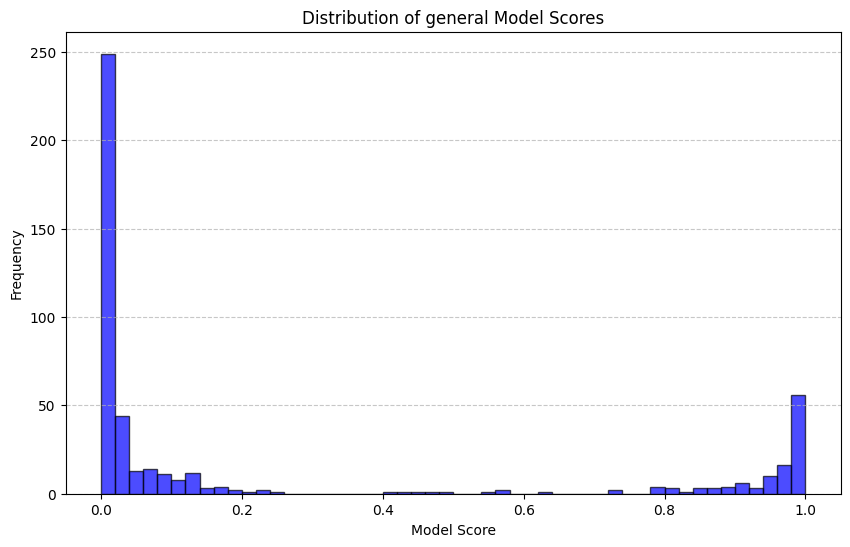

Top results for model targeting label_it:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
346,access_keys.csv,C:\Users\tiffany41\Dev\checker-framework\frame...,.csv,72461,15,70,8,1.701981e+09,1,0.999952
91,credentials.json,C:\Users\ashley31\Downloads\pimcore-master,.json,2117,16,42,4,1.713747e+09,1,0.999712
376,database.json,C:\Users\troycarroll\source\repos,.json,3701,13,33,4,1.689468e+09,1,0.999599
129,config.json,C:\Program Files\Enterprise Apps\bugsnag-andro...,.json,3202,11,62,3,1.704479e+09,1,0.999440
449,config.js,C:\Users\johnhuff\Dev\Java-Patterns\config,.js,3638,9,42,5,1.710148e+09,1,0.999401
473,config.py,C:\Users\cloud_user\Dev\commandergenius,.py,2369,9,39,4,1.696083e+09,1,0.999280
14,database.json,C:\Users\vpowers\AppData\Local,.json,1698,13,30,4,1.728630e+09,1,0.999218
150,secrets.json,C:\Work\Projects\systemd\src,.json,790,12,28,4,1.704145e+09,1,0.999207
208,firebase.json,C:\Users\gibbsandrew\source\repos\config,.json,2139,13,40,5,1.706451e+09,1,0.999192
284,.env.local,C:\Users\lunajeffrey\Desktop\Coding\config,.local,3694,10,42,5,1.702878e+09,1,0.999032


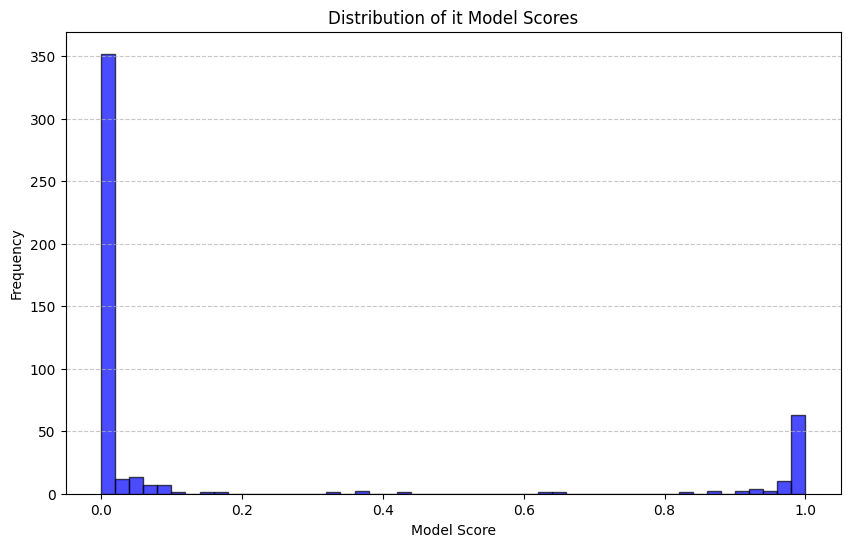

Top results for model targeting label_hr:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
305,Hochler Subdivisions Low Effect Screening Form...,Z:\HR\Recruiting\Reqs\2025\Screening\Screening,.doc,20971,64,46,6,1.695323e+09,1,0.990689
394,2025 CV Local Rules.docx,Z:\HR\Recruiting\Reqs\2024,.docx,314572,24,26,4,1.707330e+09,1,0.989762
481,TABLE 3.2 Screen_Perched rev3.doc,Z:\HR\Recruiting\Reqs\2024\Screen,.doc,20971,33,33,5,1.678799e+09,1,0.986459
272,Nr Determination Memo Final as signed January ...,Z:\HR\Operations\Policies\Determination,.docx,188743,53,39,4,1.707240e+09,1,0.985734
377,L30S1257DCVotingRights091707AC.docx,Z:\HR\Recruiting\Reqs\2024,.docx,73400,35,26,4,1.697026e+09,1,0.979999
189,Payload Description Architecture 102908v2.docx,Z:\HR\Recruiting\Reqs\2024\Payload,.docx,912261,47,34,5,1.702569e+09,1,0.979929
400,GIPSA Personnel Directory.doc,C:\Users\root\Downloads\ISOs\Personnel,.doc,83886,29,38,5,1.707394e+09,1,0.977827
220,OriLevCVSept08-1.docx,Z:\HR\Recruiting\Reqs\2024\Docx,.docx,20971,21,31,5,1.695132e+09,1,0.968270
267,ohanlon-cv-2024.docx,Z:\HR\Recruiting\Reqs\2024\Docx,.docx,104857,20,31,5,1.696357e+09,1,0.960490
312,SIS_Job Description_1.docx,Z:\HR\Recruiting\Reqs\2023,.docx,41943,26,26,4,1.707855e+09,1,0.956426


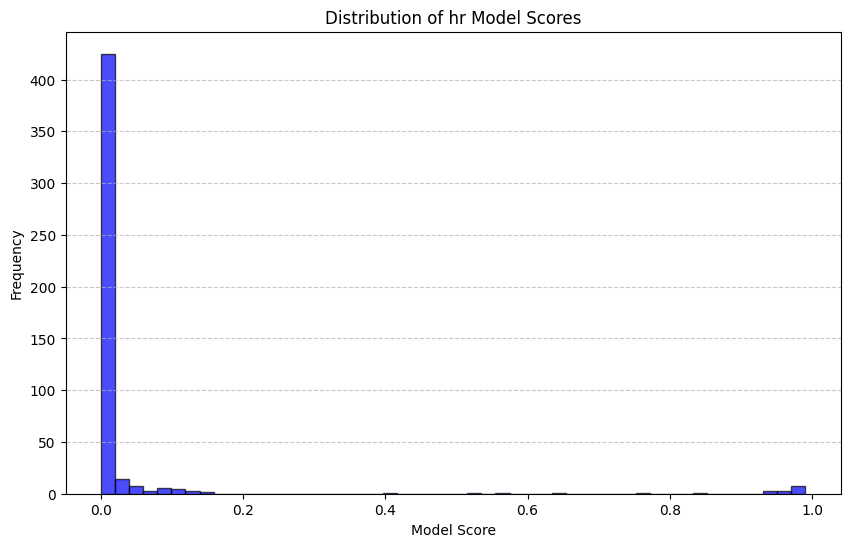

Top results for model targeting label_finance:


,filename,filepath,extension,size_bytes,name_len,path_len,path_depth,mod_time_unix,actual_label,model_score
135,BIB_2009_Compiled_3rd_Draft_Ver2_508.docx,Z:\HR\Payroll\Cycles\2023,.docx,12855541,41,25,4,1.676731e+09,1,0.996733
225,RSP-ST Stock Auth Sheet.docx,Z:\HR\Payroll\Cycles\2025\Auth,.docx,104857,28,30,5,1.695478e+09,1,0.992483
439,2024-FORECAST-EXISTING-FMS.docx,Z:\Sales\Pipeline_Reports\2023,.docx,73400,31,30,3,1.675430e+09,1,0.989741
478,budgetsummary.rtf,C:\Users\zberger\OneDrive - Corp\Finance\Repor...,.rtf,272629,17,50,5,1.517501e+09,0,0.987509
245,Accrual measures of pension-related compensati...,Z:\HR\Payroll\Cycles\2025,.docx,136314,64,25,4,1.702641e+09,1,0.982718
101,Malaria Comparison chart v4.pdf,Z:\HR\Payroll\Cycles\2024,.pdf,964689,31,25,4,1.701506e+09,1,0.956560
67,WDKY-TV - COMPREHENSIVE TECHNIC.pdf,Z:\HR\Payroll\Cycles\2023,.pdf,2044723,35,25,4,1.708041e+09,1,0.917703
229,33 -Full Cost Budgeting.docx,Z:\Finance\General_Ledger\2023,.docx,188743,28,30,3,1.668256e+09,0,0.914758
291,Pricing Schedule 58 January 2023 - Comprehensi...,Z:\HR\Payroll\Cycles\2025\January,.docx,220200,53,33,5,1.642518e+09,0,0.897158
107,compiled Word doc.docx,Z:\HR\Payroll\Cycles\2023,.docx,241172,22,25,4,1.636646e+09,0,0.816140


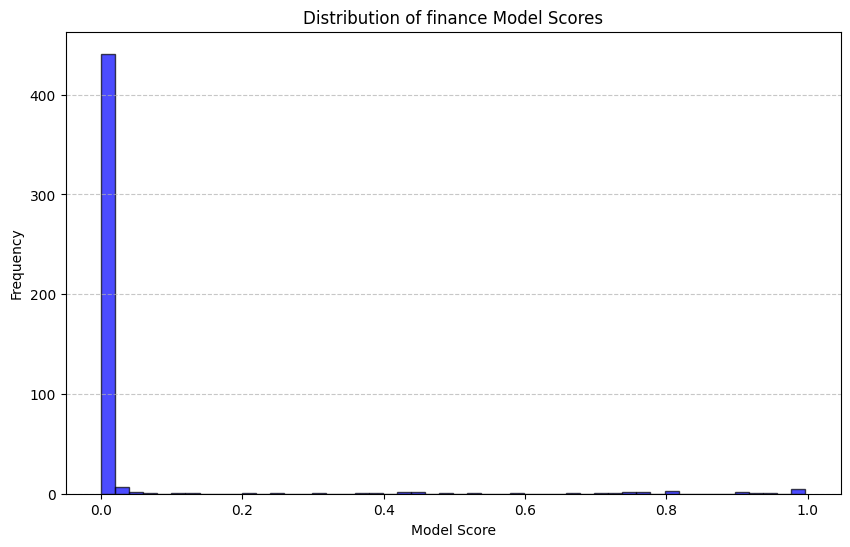

In [134]:
import matplotlib.pyplot as plt

for target, model in models_map.items():
    print(f"Top results for model targeting {target}:")

    # Get test set predictions
    y_test = df.loc[idx_test][target].values
    y_scores = model.predict_proba(X_test)[:, 1]

    results = pd.DataFrame(
        {
            "filename": df.loc[idx_test]["filename"].values,
            "filepath": df.loc[idx_test]["path"].values,
            "extension": df.loc[idx_test]["extension"].values,
            "size_bytes": df.loc[idx_test]["size_bytes"].values,
            "name_len": df.loc[idx_test]["name_len"].values,
            "path_len": df.loc[idx_test]["path_len"].values,
            "path_depth": df.loc[idx_test]["path_depth"].values,
            "mod_time_unix": df.loc[idx_test]["mod_time_unix"].values,
            "actual_label": y_test,
            "model_score": y_scores,
        }
    )

    # Sort and slice the results
    sorted_results = results.sort_values(by="model_score", ascending=False)
    display(sorted_results[:10])

    # Plot the distribution of model scores
    plt.figure(figsize=(10, 6))
    plt.hist(
        results["model_score"], bins=50, color="blue", alpha=0.7, edgecolor="black"
    )
    plt.title(f"Distribution of {target.split("_")[1]} Model Scores")
    plt.xlabel("Model Score")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Exporting weights:

In [135]:
import os

output_path = f"../include/ModelWeights.h"

# 3. Ensure Directory Exists and Write
os.makedirs(os.path.dirname(output_path), exist_ok=True)

cpp_content = f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 

#include <vector>
#include <unordered_set>
#include <string>
# """

for target, model in models_map.items():

    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()
    title = target.split("_")[1].upper()
    cpp_content += f"""
const double {title}_MODEL_BIAS = {bias:.10f};

// recency score - size_logged - valuable_ext -  junk_ext - name_len - path_len - path_depth - filename features(1024) - path features(1024)
const std::vector<double> {title}_MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> {title}_HIGH_VAL_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_extension_map[target]])}}};

const std::unordered_set<std::wstring> {title}_JUNK_EXTS = {{
{', '.join([f'L"{ext}"' for ext in target_junk_map[target]])}}};
"""

with open(output_path, "w") as f:
    f.write(cpp_content)